In [ ]:
# WSL run:  docker run -e MAPSERVER_CONFIG_FILE=/srv/data/example.conf -e MS_MAPFILE=/srv/data/brt-achtergrondkaart-standaard-zonder-gebouwen.map -e SERVICE_TYPE=WMS --rm -p 80:80 --name mapserver-example -v `pwd`/example:/srv/data pdok/mapserver

import json
import os
import requests

json_path = "".join([os.getcwd(), "\\zutphen-met-labels.json"])
output_folder1 = "".join([os.getcwd(), "\\zutphen-zonder-gebouwen-map"])
timeout_seconds = 5

if not os.path.exists(output_folder1):
    os.makedirs(output_folder1)

with open(json_path, 'r') as f:
    data = json.load(f)

print(f"Start met downloaden van {len(data)} afbeeldingen...")

for index, item in enumerate(data):
    url = item.get("URL")
    if not url:
        print(f"Skipping index {index}: Geen URL gevonden.")
        continue
    try:
        filename = f"image_{index}.jpg"
        save_path = os.path.join(output_folder1, filename)
        response = requests.get(url, timeout=timeout_seconds)
        if response.status_code == 200:
            with open(save_path, 'wb') as img_file:
                img_file.write(response.content)
            print(f"Succes: {filename} opgeslagen.")
        else:
            print(f"Fout bij {url}: Status {response.status_code}")
    except Exception as e:
        print(f"Fout bij downloaden van {url}: {e}")


NameError: name 'output_folder1' is not defined

In [ ]:
#WSL run:  docker run -e MAPSERVER_CONFIG_FILE=/srv/data/example.conf -e MS_MAPFILE=/srv/data/brt-achtergrondkaart-standaard-only-marked-labels.map -e SERVICE_TYPE=WMS --rm -p 80:80 --name mapserver-example -v `pwd`/example:/srv/data pdok/mapserver

import json
import os
import requests

json_path = "".join([os.getcwd(), "\\zutphen-met-labels.json"])
output_folder2 = "".join([os.getcwd(), "\\zutphen-met-alleen-labels-map"])
timeout_seconds = 5

if not os.path.exists(output_folder2):
    os.makedirs(output_folder2)

with open(json_path, 'r') as f:
    data = json.load(f)

print(f"Start met downloaden van {len(data)} afbeeldingen...")

for index, item in enumerate(data):
    url = item.get("URL")
    if not url:
        print(f"Skipping index {index}: Geen URL gevonden.")
        continue
    try:
        filename = f"image_{index}.jpg"
        save_path = os.path.join(output_folder2, filename)
        response = requests.get(url, timeout=timeout_seconds)
        if response.status_code == 200:
            with open(save_path, 'wb') as img_file:
                img_file.write(response.content)
            print(f"Succes: {filename} opgeslagen.")
        else:
            print(f"Fout bij {url}: Status {response.status_code}")
    except Exception as e:
        print(f"Fout bij downloaden van {url}: {e}")

Start met downloaden van 625 afbeeldingen...
Succes: image_0.jpg opgeslagen.
Succes: image_1.jpg opgeslagen.
Succes: image_2.jpg opgeslagen.
Succes: image_3.jpg opgeslagen.
Succes: image_4.jpg opgeslagen.
Succes: image_5.jpg opgeslagen.
Succes: image_6.jpg opgeslagen.
Succes: image_7.jpg opgeslagen.
Succes: image_8.jpg opgeslagen.
Succes: image_9.jpg opgeslagen.
Succes: image_10.jpg opgeslagen.
Succes: image_11.jpg opgeslagen.
Succes: image_12.jpg opgeslagen.
Succes: image_13.jpg opgeslagen.
Succes: image_14.jpg opgeslagen.
Succes: image_15.jpg opgeslagen.
Succes: image_16.jpg opgeslagen.
Succes: image_17.jpg opgeslagen.
Succes: image_18.jpg opgeslagen.
Succes: image_19.jpg opgeslagen.
Succes: image_20.jpg opgeslagen.
Succes: image_21.jpg opgeslagen.
Succes: image_22.jpg opgeslagen.
Succes: image_23.jpg opgeslagen.
Succes: image_24.jpg opgeslagen.
Succes: image_25.jpg opgeslagen.
Succes: image_26.jpg opgeslagen.
Succes: image_27.jpg opgeslagen.
Succes: image_28.jpg opgeslagen.
Succes: 

In [1]:
from PIL import Image
import numpy as np
import os

input_image_array = np.empty([625,512,512,3], dtype=np.int16)
target_image_array = np.empty([625,512,512,3], dtype=np.int16)

for i in range(625):
    image_path1 = "".join([os.getcwd(), "\\zutphen-zonder-gebouwen-map\\image_",str(i),".jpg"])
    image1 = Image.open(image_path1)
    image_array1 = np.array(image1)
    input_image_array[i] = np.delete(np.delete(np.delete(image_array1, np.s_[512::], 0),np.s_[512::], 1),np.s_[3::], 2)

    image_path2 = "".join([os.getcwd(), "\\zutphen-met-alleen-labels-map\\image_", str(i),".jpg"])
    image2 = Image.open(image_path2)
    image_array2 = np.array(image2)
    target_image_array[i] = np.delete(np.delete(np.delete(image_array2, np.s_[512::], 0),np.s_[512::], 1),np.s_[3::], 2)

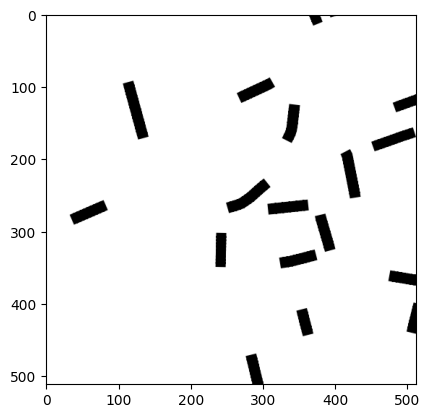

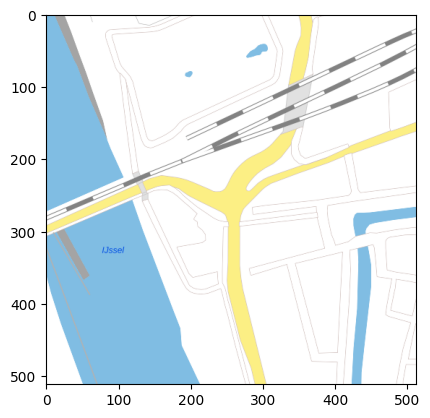

In [2]:
import matplotlib.pyplot as plt

plt.imshow(target_image_array[0])
plt.show()

plt.imshow(input_image_array[0])
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_image_array, target_image_array, test_size=0.2, random_state=42)
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [4]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


def create_model(img_width, img_height):

    x = Input(shape=(img_width, img_height, 3))

    # Encoder - compresses the input into a latent representation
    e_conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    pool1 = MaxPooling2D((2, 2), padding='same')(e_conv1)
    batchnorm_1 = BatchNormalization()(pool1)

    e_conv2 = Conv2D(32, (3, 3), activation='relu', padding='same')(batchnorm_1)
    pool2 = MaxPooling2D((2, 2), padding='same')(e_conv2)
    batchnorm_2 = BatchNormalization()(pool2)

    e_conv3 = Conv2D(16, (3, 3), activation='relu', padding='same')(batchnorm_2)
    h = MaxPooling2D((2, 2), padding='same')(e_conv3)

    # Decoder - reconstructs the input from a latent representation
    d_conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(h)
    up1 = UpSampling2D((2, 2))(d_conv1)

    d_conv2 = Conv2D(32, (3, 3), activation='relu', padding='same')(up1)
    up2 = UpSampling2D((2, 2))(d_conv2)

    d_conv3 = Conv2D(16, (3, 3), activation='relu', padding="same")(up2)
    up3 = UpSampling2D((2, 2))(d_conv3)

    r = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(up3)

    model = Model(x, r)
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
    return model

In [22]:
model = create_model(512, 512)
model.summary()

history = model.fit(x_train, y_train, epochs=10, batch_size=4, validation_data=(x_test, y_test))

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 512, 512, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 512, 512, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 512, 512, 3)    │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,067 (226.82 KB)

 Trainable params: 57,875 (226.07 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 307ms/step - loss: 61362.1680 - val_loss: 61183.5938
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 312ms/step - loss: 61354.7227 - val_loss: 61183.5938
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 308ms/step - loss: 61354.7109 - val_loss: 61183.5938
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 301ms/step - loss: 61354.7188 - val_loss: 61183.5938
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 346ms/step - loss: 61354.6992 - val_loss: 61183.5938
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 323ms/step - loss: 61354.7266 - val_loss: 61183.5938
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 321ms/step - loss: 61354.7031 - val_loss: 61183.5938
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 349ms/step - loss: 61354.7070 - val_loss: 61183.5938
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 316ms/step - loss: 61354.7266 - val_loss: 61183.5938
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 353ms/step - loss: 61354.7109 - val_loss: 61183.5938


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 538ms/step


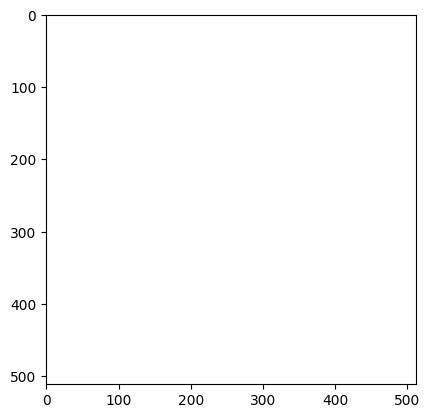

0.98859584


In [ ]:
prediction = model.predict(x_test)
plt.imshow(prediction[0])
plt.show()

[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 1. 0.]
  ...
  [0. 0. 1.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 1. 0.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 0. 1.]
  [0. 0. 0.]]

 [[1. 1. 0.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [0. 0. 0.]]

 ...

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [0. 0. 0.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [0. 1. 1.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 1. 1.]
  [1. 1. 1.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


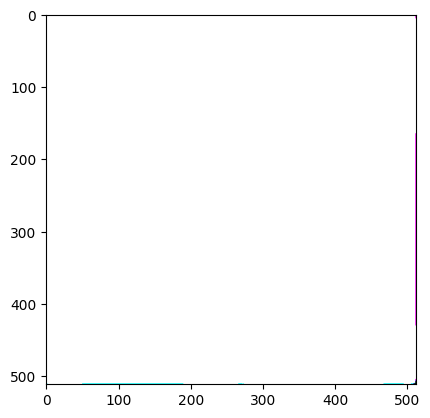

In [48]:
prediction[prediction!=1] = 0
prediction = np.array(prediction, dtype=float)
print(prediction[0])
plt.imshow(prediction[0])

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_unet_map_labeler(input_shape=(512, 512, 3)):
    inputs = layers.Input(input_shape)

    # Helper function for a double convolution block
    def conv_block(x, filters):
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    # --- ENCODER (Downsampling) ---
    f1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(f1)

    f2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(f2)

    f3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D((2, 2))(f3)

    # --- BOTTLE NECK ---
    bottleneck = conv_block(p3, 512)

    # --- DECODER (Upsampling) ---
    u3 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(bottleneck)
    u3 = layers.concatenate([u3, f3])
    f4 = conv_block(u3, 256)

    u2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(f4)
    u2 = layers.concatenate([u2, f2])
    f5 = conv_block(u2, 128)

    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(f5)
    u1 = layers.concatenate([u1, f1])
    f6 = conv_block(u1, 64)

    # --- OUTPUT (Heatmap) ---
    # 1 channel (512, 512, 1) with sigmoid to get float values [0.0, 1.0]
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(f6)

    model = models.Model(inputs, outputs, name="U-Net_RoadLabeler")
    return model

# Initialize
model = build_unet_map_labeler()

# Use Adam optimizer and Mean Squared Error for Heatmap regression
# Or Binary Crossentropy if your labels are strictly 0 or 1
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "U-Net_RoadLabeler"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_4[0][0]  

 Total params: 7,708,609 (29.41 MB)

 Trainable params: 7,702,977 (29.38 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [6]:
history = model.fit(x_train, y_train, epochs=10, batch_size=4, validation_data=(x_test, y_test))

Epoch 1/10
 21/125 ━━━━━━━━━━━━━━━━━━━━ 15:21 9s/step - loss: 61174.7746 - mae: 240.9234

KeyboardInterrupt: 